# 03: Geographic & Mode Dashboard

**Goal:** Interactive view of capital distribution across states, metro areas, and transit modes.

**Data:** FTA NTD Capital Expenses, 2024 — 1,000 records

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
df = pd.read_csv('../data/ntd_capital_expenses.csv')
numeric_cols = ['guideway','stations','administrative_buildings','maintenance_buildings',
                'passenger_vehicles','other_vehicles','fare_collection_equipment',
                'communication_information','other','total','primary_uza_population']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f"Records: {len(df)}")
df.head()

Records: 1000


,agency,city,state,ntd_id,organization_type,reporter_type,report_year,uace_code,uza_name,primary_uza_population,...,fare_collection_equipment,fare_collection_equipment_1,communication_information,communication_information_1,other,other_questionable,reduced_reporter,reduced_reporter_questionable,total,total_questionable
0,"King County, dba: King County Metro",Seattle,WA,1,"City, County or Local Government Unit or Depar...",Full Reporter,2024,80389.0,"Seattle--Tacoma, WA",3544011.0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
1,"King County, dba: King County Metro",Seattle,WA,1,"City, County or Local Government Unit or Depar...",Full Reporter,2024,80389.0,"Seattle--Tacoma, WA",3544011.0,...,0,NaN,0,NaN,16077568,NaN,0,NaN,43483088,NaN
2,"King County, dba: King County Metro",Seattle,WA,1,"City, County or Local Government Unit or Depar...",Full Reporter,2024,80389.0,"Seattle--Tacoma, WA",3544011.0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
3,"King County, dba: King County Metro",Seattle,WA,1,"City, County or Local Government Unit or Depar...",Full Reporter,2024,80389.0,"Seattle--Tacoma, WA",3544011.0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
4,"King County, dba: King County Metro",Seattle,WA,1,"City, County or Local Government Unit or Depar...",Full Reporter,2024,80389.0,"Seattle--Tacoma, WA",3544011.0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


## State Capital Heatmap

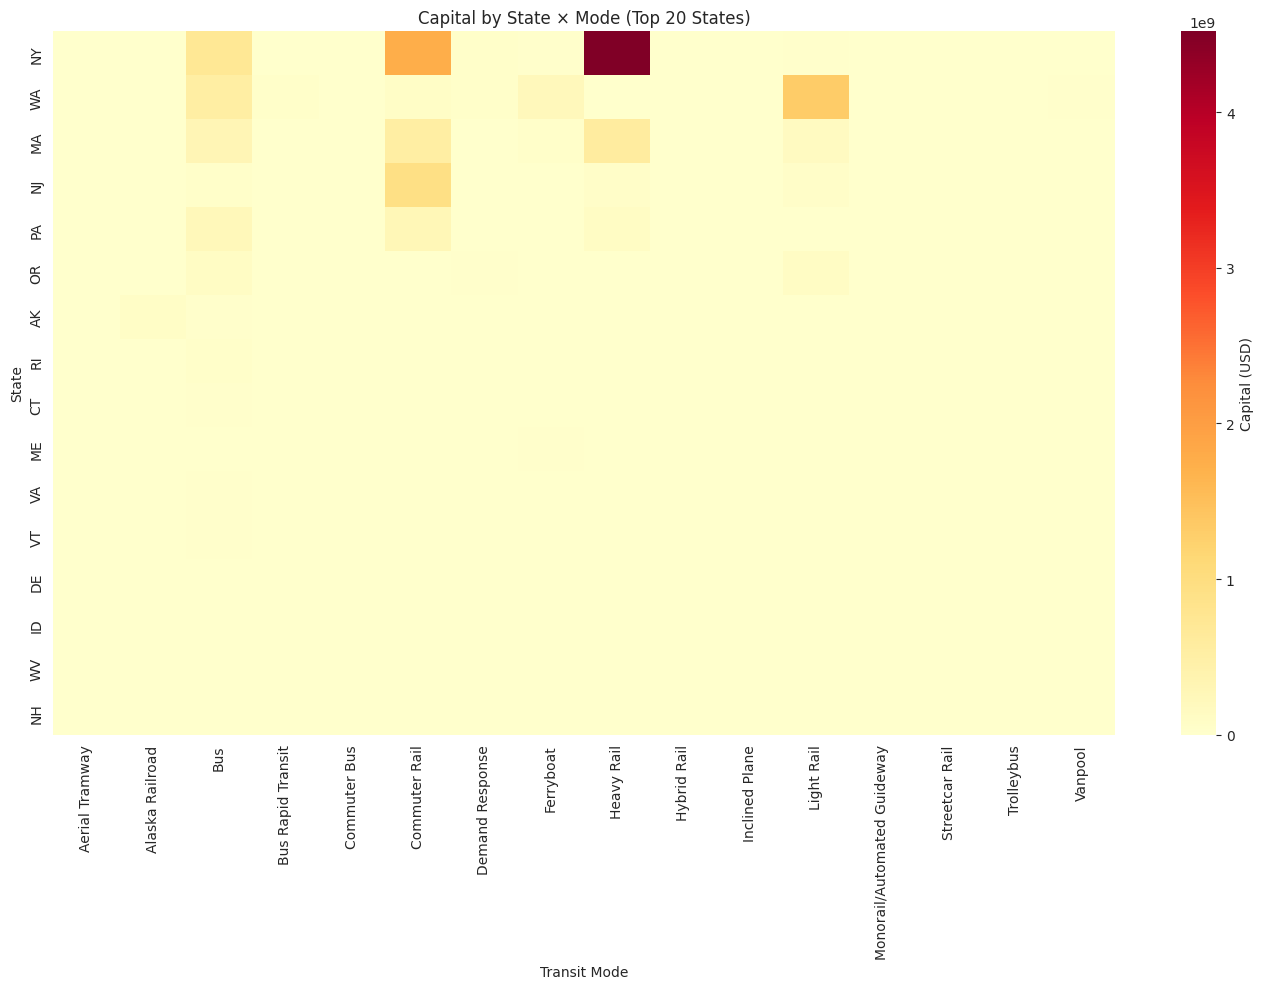

In [3]:
state_pivot = df.groupby(['state','mode_name'])['total'].sum().unstack(fill_value=0)
state_pivot = state_pivot.loc[state_pivot.sum(axis=1).sort_values(ascending=False).head(20).index]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(state_pivot, annot=False, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Capital (USD)'})
ax.set_title('Capital by State × Mode (Top 20 States)')
ax.set_xlabel('Transit Mode')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

## Metro Area Comparison

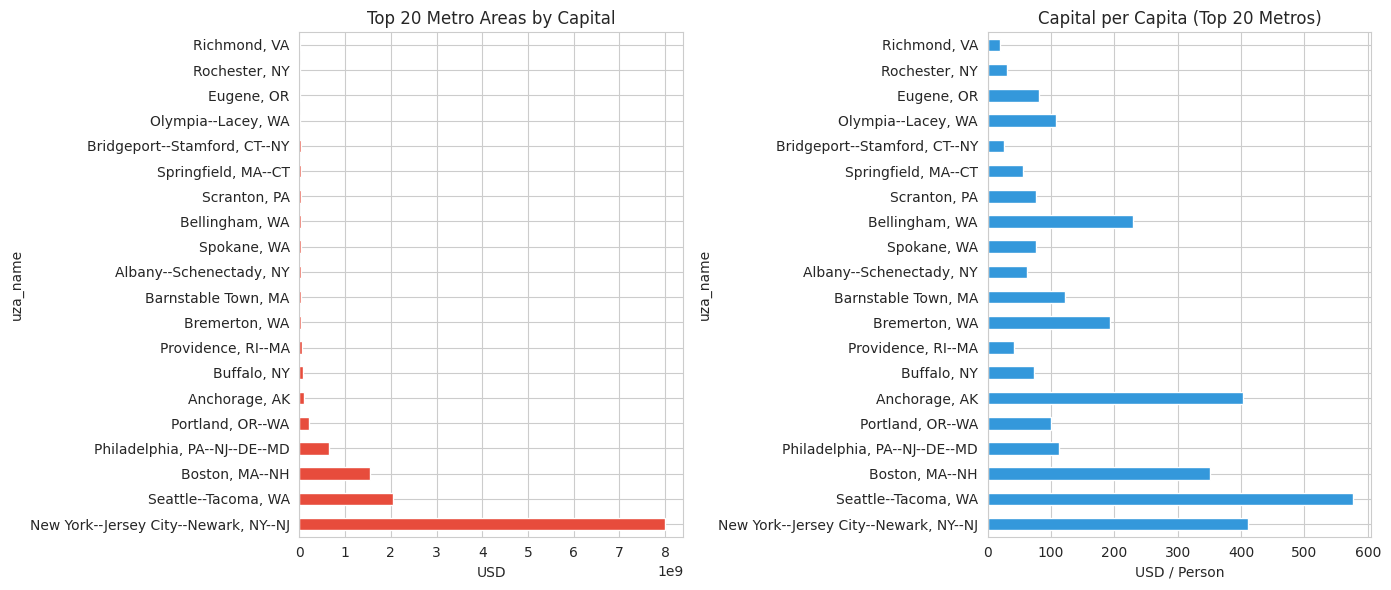

In [4]:
metro = df.groupby('uza_name').agg({
    'total': 'sum',
    'primary_uza_population': 'first',
    'agency': 'nunique'
}).sort_values('total', ascending=False).head(20)

metro['cost_per_capita'] = metro['total'] / metro['primary_uza_population']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metro['total'].plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 20 Metro Areas by Capital')
axes[0].set_xlabel('USD')

metro['cost_per_capita'].plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Capital per Capita (Top 20 Metros)')
axes[1].set_xlabel('USD / Person')

plt.tight_layout()
plt.show()

## Mode Portfolio Pie

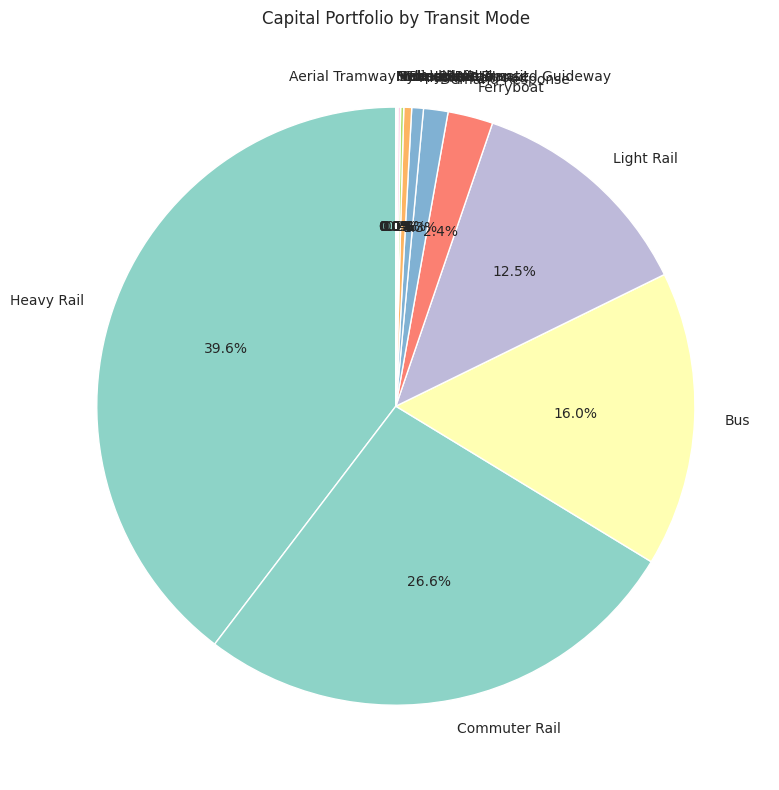

In [5]:
mode_total = df.groupby('mode_name')['total'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(mode_total)))
wedges, texts, autotexts = ax.pie(mode_total, labels=mode_total.index, autopct='%1.1f%%',
                                   colors=colors, startangle=90)
ax.set_title('Capital Portfolio by Transit Mode')
plt.tight_layout()
plt.show()